Sudoku is a game where you have a 9x9 grid where you need to fill each row, column, and 3x3 subgrid with unique combinations of the integers 1-9.

It's interesting to try to develop a solver for this that is based off continous numbers, rather than discrete ones, because then we can use standard techniques from continous minimization, like gradient descent, to try to solve this.

The question is, then, how do you map 

1) integer constraints to continous variables

2) the rules of sudoku to a minimization problem

The first problem is not too hard to tackle if we consider a dynamical system that has steady states at integer values.

Consider a dynamical system that has a double well potential, like a ball rolling down a hill that has two divets in it. The ball should naturally land in one of the dips of the hill:

The energy would look something like:

$$ E = x^2 (1-x)^2$$

Inspecting this, when $x=0$, $E=0$, or when $x=1$, $E=0$, anywhere else $E$ is greater than $0$.

So this has stable states at $x=\{0,1\}$

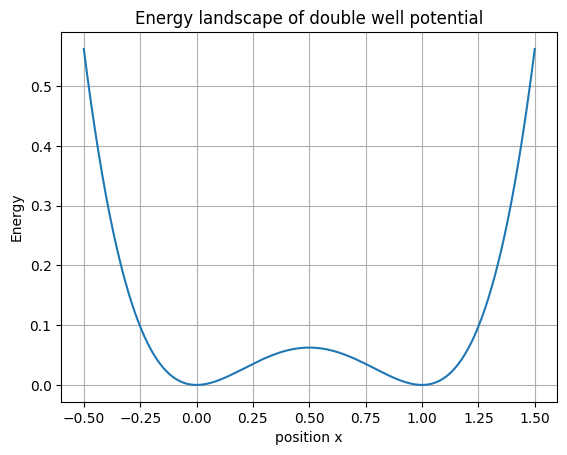

In [17]:
import numpy as np
import matplotlib.pyplot as plt

xx = np.linspace(-.5,1.5, 1000)

E = (xx-1)**2 * xx**2
plt.plot(xx, E)
plt.title("Energy landscape of double well potential")
plt.grid()
plt.xlabel("position x")
plt.ylabel("Energy")
plt.show()

This is actually how gradient descent works, a particle moves in the direction that minimizes the local energy, that is:

$$ \frac{\partial x}{\partial t} = -\frac{\partial E}{\partial x} = -\nabla E$$

Or the movement (velocity $dx/dt$) of the particle $x$ is against the energy's gradient (so it moves "downhill" in this example).

To note, if the ball started at $x=0.5$ it would be stuck there, but that state is unstable, since any perturbation from that point would lead it to either $x=0$ or $x=1$.

We can see this by plotting the gradient and its flow. We see that the arrows flow inward at the stable fixed points, and outwards at the unstable fixed points.

$$\nabla E = 2x (1-x)^2 -2 x^2 (1-x)$$

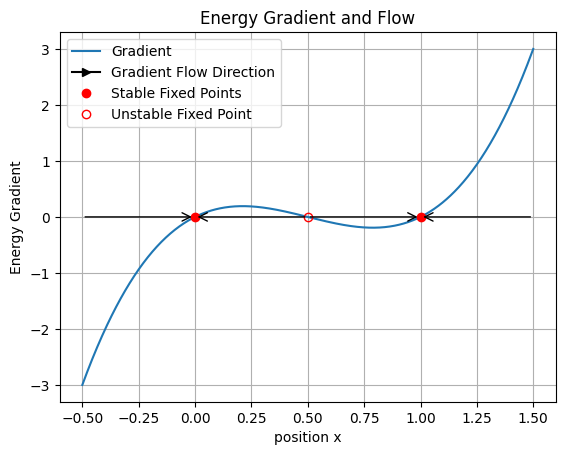

In [33]:
def plot_flow(x, gradField, ax):
    signs = np.sign(gradField)
    indices = np.arange(len(signs)-1)[np.nonzero(np.diff(signs))] # change in sign is change in direction or stability
    indices = np.concat([[0], indices, [-1]])
    xx = x[indices]
    for i in range(len(xx)-1):
        x0, x1 = xx[i], xx[i+1]
        direction = signs[indices[i]+1]

        xStart = x0 if direction > 0 else x1
        xEnd = x1 if direction > 0 else x0
        ax.annotate(
            '',
            xy=(xStart, 0),
            xytext=(xEnd, 0),
            arrowprops=dict(arrowstyle="->"),
            size=15
        )
gradE = 2*xx*(xx-1)**2  - 2 * xx**2 * (1-xx)

plt.figure()
plt.plot(xx, gradE, label='Gradient')
plt.plot([], [], 'k->', label='Gradient Flow Direction')
plt.plot([0, 1], [0,0], 'ro', label='Stable Fixed Points')
plt.plot([0.5], [0], 'ro', markerfacecolor='none', label='Unstable Fixed Point')
plot_flow(xx, gradE, plt)
plt.legend()
plt.title("Energy Gradient and Flow")
plt.grid()
plt.xlabel("position x")
plt.ylabel("Energy Gradient")
plt.show()


So we now have a way of encoding discrete variables into continuous - the steady state value of our variable (or particle) will be 0 or 1, discrete.

This leaves a choice for how to encode the 9 numbers of sudoku.

We could put 9 fixed points (one at each integer between 1 and 9) in our energy function, or do a one hot encoding strategy, where 1 through 9 is is encoded in 9 variables, where only 1 variable is allowed to be on at a time. The variable that is 1 is the state of the sudoku cell. For example if the third variable is 1, the other variables should be 0, and that cell is encoding the value 3 (even though the value of the variable is just 1).

The one hot encoding strategy is advantageous in this case, since we can use a simliar strategy for the second constraint mapping.

That is, if we want each column, for example to only have one of each integer 1 - 9, we can allow only one of the 1s in the hot encoding in the column to be activated per cell.

This makes all of our dynamics a lot simpler to model.

To do one hot encoding per cell (or column, row, or subgrid), we can write:

$$ E_{\text{cell}} = \left(1-\sum_{x_i \in cell}x_i\right)^2$$

This cell energy constraint encodes a minimum when the sum is equal to 1. 

So, if all variables in the cell are simulatenoulsy 0 or 1, and we take this cell constraint into account, we get that only 1 variable in the cell can be on.

The total energy energy is now:

$$ E = E_{\text{binary}} + E_{\text{cell}}$$

And each variable gets a gradient:

$$ \frac{\partial x_i}{\partial t} = -\frac{\partial E_{\text{binary}}}{\partial x_i}   -\frac{\partial E_{\text{cell}}}{\partial x_i}$$


To be clear, this means that each cell has 9 variables, and there are 9x9 = 81 cells in sudoku, so 729 variables total.

We can make simliar constraints for the rows, columns, and subgrids. That is, each row, col, and subgrid can only have one 1 on at once, one 2 on at once, etc. all the way through 9.



As an example, we can write that the first row can only have one 1 at once:

$$ E_{\text{row,1,1}} = \left(1-\sum_{x_i \in{\text{row,1,1} }} x_i\right)^2$$


The total energy is, then:

$$\begin{aligned}E = &\sum_{\text{variables}}E_{\text{variable, binary constraint}} \\
&+ \sum_\text{cell, hot encodings}E_{\text{cell, hot encoding}}\\
&+ \sum_\text{rows, hot encodings}E_{\text{row, hot encoding}}\\
&+ \sum_\text{columns, hot encodings}E_{\text{column, hot encoding}}\\
&+ \sum_\text{sub-grids, hot encodings}E_{\text{sub-grid, hot encoding}}\\
\end{aligned}$$


We just have to careful how we index all the variables, to gather the correct $x_i$ variables for each constraint.

The equations of motion are then (in a bit of shorthand notation, dropping sums):

$$ \frac{\partial x_i}{\partial t} = -\frac{\partial E_{\text{binary}}}{\partial x_i}   - \frac{\partial E_{\text{cell}}}{\partial x_i} -  \frac{\partial E_{\text{row}}}{\partial x_i} -  \frac{\partial E_{\text{column}}}{\partial x_i} -  \frac{\partial E_{\text{sub-grid}}}{\partial x_i}$$


Each of these gradients work out to be, for each type of constraint:

$$ \frac{\partial E_{\text{constraint}}}{x_i} = -2\left(1-\sum_{x_i \in{\text{constraint} }} x_i\right)x_i$$

One thing we glossed over is how should we have combined the energies?

We just did a sum of the different energies, but should we have done a weighted sum? Maybe at certain points we should care about one energy function more than another...

To capture this we can make the weights of the energy functions time varying, so go from this:

$$ E = \sum_{\text{constraints}} E_{\text{constraint}}$$

To this:

$$ E = \sum_{\text{constraints}} \lambda_{\text{constraint}}E_{\text{constraint}}$$


$$ \frac{\partial x_i}{\partial t} = -\lambda_{\text{binary}}\frac{\partial E_{\text{binary}}}{\partial x_i}   - \lambda_{\text{cell}}\frac{\partial E_{\text{cell}}}{\partial x_i} -  \lambda_{\text{row}}\frac{\partial E_{\text{row}}}{\partial x_i} -  \lambda_{\text{column}}\frac{\partial E_{\text{column}}}{\partial x_i} - \lambda_{\text{sub-grid}}\frac{\partial E_{\text{sub-grid}}}{\partial x_i}$$

$$ \frac{\partial \lambda_{\text{constraint}}}{\partial t} = E_{\text{constraint}}$$


What this enforces, is that when a constraint is satisfied, i.e.e $E_{\text{constraint}}=0$, then its corresponding $\lambda$ stops growing.

However, when its $E$ is violated ($E > 0$), then $\lambda$ grows proportionally, and the gradient increases. This allows the dynamics to self correct for how the constraints shoud we weighted or added together.

In summary, if we have our variables simulatenously satisfy the energy constraints:
1. Each variable is in the 0 or 1 minima.
2. Each cell only has one of its 9 variables on (evaluating to 1)
3. Each row, column, and subgrid has only one of each hot encoded cell on (one 1, one 2, one 3, ..., one 9), then:

Sudoku should be solved.